<div style="background:linear-gradient(135deg,#4c0519 0%,#9f1239 55%,#fb7185 100%);border-radius:18px;padding:32px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#fecdd3;font-weight:700;text-transform:uppercase">Chapter 183 &middot; Capstone 23 &middot; Propensity Scores</div>
  <div style="font-size:32px;font-weight:900;line-height:1.1;margin:10px 0 6px">Matching, Weighting, and What Neither Can Reach</div>
  <div style="font-size:15px;color:#fecdd3;max-width:820px;line-height:1.6">Every measured covariate balances to three decimal places. The estimate barely moves, and it is entirely bias. This notebook does the analysis properly first, and only then opens the sheet that explains it.</div>
</div>

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
plt.rcParams.update({"figure.dpi":110,"font.size":11,"axes.spines.top":False,"axes.spines.right":False,
    "axes.grid":True,"grid.alpha":0.22,"axes.titleweight":"bold","axes.titlesize":12.5,"axes.titlelocation":"left"})
RS, DK, LT, MUT, GD = "#9f1239", "#4c0519", "#fb7185", "#94a3b8", "#047857"

BASE = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
fn = "capstone-propensity-score-matching.xlsx"
def load(sheet):
    try:    return pd.read_excel("../../data/" + fn, sheet_name=sheet)
    except FileNotFoundError: return pd.read_excel(BASE + fn, sheet_name=sheet)
obs  = load("Observed")
plan = load("AnalysisPlan")
print("rows in the HR export:", len(obs))
obs.head()

rows in the HR export: 4055


,employee_id,department,education,age,tenure_years,prior_rating,prior_salary,enrolled,salary_growth_pct
0,E22047,Engineering,Bachelor,33,5.9,2.0,37700,1,3.00
1,E22186,Engineering,High school,45,6.1,3.0,50100,0,5.12
2,E22820,Engineering,Bachelor,59,0.4,4.0,38300,1,1.84
3,E21707,Engineering,High school,47,4.5,3.0,56500,0,0.22
4,E23991,Engineering,Bachelor,53,4.0,3.0,49000,1,5.29


## Step 1 &middot; The plan, and why this is not an experiment

Nobody was randomized. Employees decided for themselves whether to enroll, which means the two groups differ in every way that influenced that decision, only some of which anybody wrote down.

In [2]:
for line in plan.analysis_plan.fillna(""):
    print(line)

WRITTEN BEFORE THE OUTCOME DATA WERE LINKED IN.

A1 QUESTION: does the voluntary management-training program raise 12-month salary growth?
A2 WHY THIS IS NOT AN EXPERIMENT: employees chose whether to enroll. Nobody was randomized, and
   the people who enroll are not the people who did not.
A3 ESTIMAND: the average treatment effect on the treated (ATT). We want to know what the program
   did for the people who actually took it, not what it would do for everyone.
A4 COVARIATES, fixed now: department, education, age, tenure, prior performance rating, prior
   salary. All of them measured BEFORE enrollment, so none can have been affected by the program.
A5 PROPENSITY MODEL: logistic regression of enrollment on the A4 covariates.
A6 COMMON SUPPORT: trim to the region where both groups appear. Employees with no plausible
   counterpart are dropped and the number dropped is reported.
A7 PRIMARY ANALYSIS: 1:1 nearest-neighbor matching on the logit of the propensity score, with a
   caliper o

**Read A4 and A10 together.** A4 lists what we can adjust for. A10 exists because that list is not the same as the list of things that mattered, and no amount of care with the first list closes the gap to the second.

## Step 2 &middot; Cleaning

In [3]:
d = obs.drop_duplicates(subset="employee_id").copy()
print(f"raw rows                  {len(obs)}")
print(f"after the duplicate export {len(d)}")
d["department"] = d.department.str.title().str.strip()
d.loc[d.tenure_years == -1, "tenure_years"] = np.nan     # -1 is a sentinel, not a tenure
print(f"\nmissing prior rating      {d.prior_rating.isna().sum()}")
print(f"tenure sentinels voided   {d.tenure_years.isna().sum()}")
d = d.dropna(subset=["prior_rating", "tenure_years"])
print(f"\ncomplete cases            {len(d)}   enrolled {d.enrolled.sum()} ({d.enrolled.mean():.1%})")

raw rows                  4055
after the duplicate export 4000

missing prior rating      90
tenure sentinels voided   30

complete cases            3880   enrolled 1247 (32.1%)


**Complete-case analysis is a decision, not a default.** A hundred and twenty employees are dropped here because a rating or a tenure is missing. That is defensible only if the missingness is unrelated to the outcome, which is an assumption nobody has tested. Capstone 31 is about exactly this; for now it is disclosed rather than solved.

## Step 3 &middot; First look

Before any score is fitted, look at who enrolled. If the two groups were drawn from the same population this step would be dull. It is not.

In [4]:
print(f"{'':22s}{'enrolled':>12}{'did not':>12}{'gap':>10}")
for c, fmt in [("age","{:.1f}"), ("tenure_years","{:.2f}"), ("prior_rating","{:.3f}"),
               ("prior_salary","{:,.0f}"), ("salary_growth_pct","{:.3f}")]:
    a, b = d[d.enrolled==1][c].mean(), d[d.enrolled==0][c].mean()
    print(f"  {c:20s}{fmt.format(a):>12}{fmt.format(b):>12}{(a-b)/d[c].std():>+10.3f}")
print("\n(the gap column is in standard deviations of the pooled column)")
print(f"\nprior_salary, five-number summary")
print(d.prior_salary.describe(percentiles=[.25,.5,.75]).round(0).to_string())
print(f"\nENROLLMENT RATE BY DEPARTMENT")
for dep, g in d.groupby("department"):
    print(f"  {dep:16s} {len(g):5,} employees   {g.enrolled.mean():6.1%} enrolled")

                          enrolled     did not       gap
  age                         37.5        38.2    -0.081
  tenure_years                4.66        5.20    -0.158
  prior_rating               3.411       3.163    +0.283
  prior_salary              46,996      46,924    +0.009
  salary_growth_pct          4.491       2.662    +0.757

(the gap column is in standard deviations of the pooled column)

prior_salary, five-number summary
count     3880.0
mean     46947.0
std       7899.0
min      22900.0
25%      41100.0
50%      46900.0
75%      52700.0
max      76200.0

ENROLLMENT RATE BY DEPARTMENT
  Engineering      1,028 employees    35.0% enrolled
  Operations       1,242 employees    28.7% enrolled
  Sales              934 employees    36.4% enrolled
  Support            676 employees    28.1% enrolled


**What this shows.** The two groups are not simply better and worse versions of each other. The employees who enrolled were rated a quarter of a standard deviation higher the year before, and they had been at the company about six months less. Their pay was the same to within a rounding error. That specific pattern is the problem: enrollment was not random, it followed something, and the outcome column already shows the enrolled growing their salary at nearly twice the rate. The department rates say the same thing from another angle, running from 28 percent in Support to 36 percent in Sales.

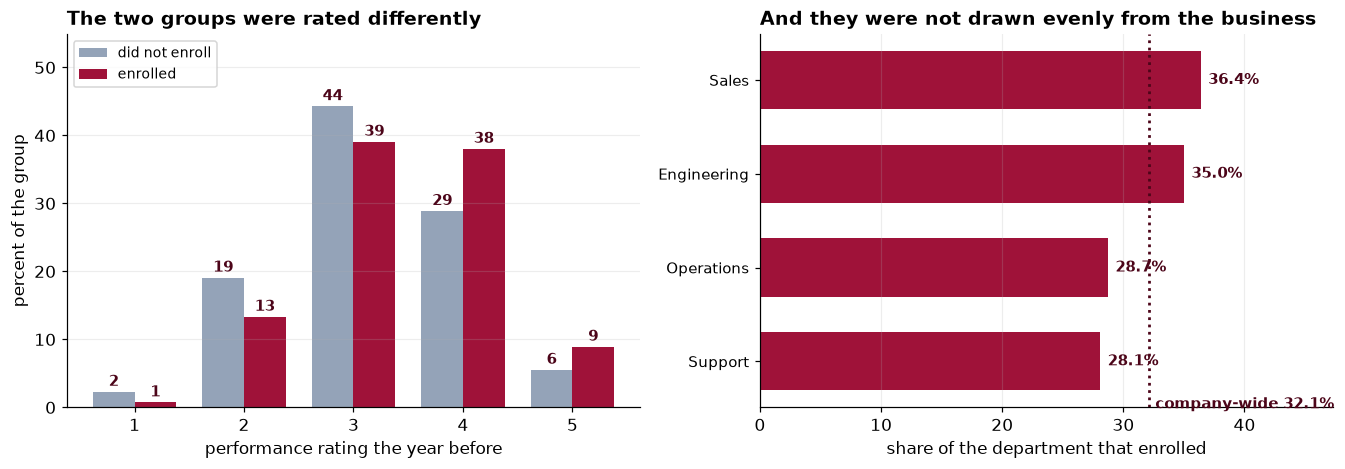

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.4))

ax = axes[0]
vals = sorted(d.prior_rating.dropna().unique())
xp, w = np.arange(len(vals)), 0.38
sh0 = [(d[d.enrolled==0].prior_rating == v).mean()*100 for v in vals]
sh1 = [(d[d.enrolled==1].prior_rating == v).mean()*100 for v in vals]
ax.bar(xp - w/2, sh0, width=w, color=MUT, label="did not enroll")
ax.bar(xp + w/2, sh1, width=w, color=RS, label="enrolled")
for x, v in zip(xp - w/2, sh0):
    ax.text(x, v + 0.9, f"{v:.0f}", ha="center", fontsize=9.5, fontweight="bold", color=DK)
for x, v in zip(xp + w/2, sh1):
    ax.text(x, v + 0.9, f"{v:.0f}", ha="center", fontsize=9.5, fontweight="bold", color=DK)
ax.set_xticks(xp); ax.set_xticklabels([f"{v:.0f}" for v in vals])
ax.set_ylim(0, max(max(sh0), max(sh1))*1.24)
ax.set_xlabel("performance rating the year before")
ax.set_ylabel("percent of the group")
ax.set_title("The two groups were rated differently")
ax.legend(fontsize=9, loc="upper left"); ax.grid(axis="x", alpha=0)

ax = axes[1]
rate = d.groupby("department").enrolled.mean().sort_values()
ax.barh(range(len(rate)), rate.values*100, color=RS, height=0.62)
for i, v in enumerate(rate.values*100):
    ax.text(v + 0.6, i, f"{v:.1f}%", va="center", fontsize=10, fontweight="bold", color=DK)
ax.axvline(d.enrolled.mean()*100, color=DK, lw=1.8, ls=":")
ax.text(d.enrolled.mean()*100 + 0.5, -0.46, f"company-wide {d.enrolled.mean():.1%}",
        fontsize=9.5, fontweight="bold", color=DK, va="center")
ax.set_yticks(range(len(rate))); ax.set_yticklabels(rate.index, fontsize=10)
ax.set_xlim(0, rate.max()*100*1.30)
ax.set_xlabel("share of the department that enrolled")
ax.set_title("And they were not drawn evenly from the business")
ax.grid(axis="y", alpha=0)
plt.tight_layout(); plt.show()

**Left:** the shapes cross over. More of the people who stayed away were rated 2 and 3, more of the people who enrolled were rated 4 and 5. **Right:** no department sits on the company-wide line. Both panels describe selection on things that were written down, and that is the easy half. The half that decides this study is selection on things nobody recorded, which no picture of this file can show.

## Step 4 &middot; The naive comparison

In [6]:
t0, c0 = d[d.enrolled == 1], d[d.enrolled == 0]
diff0 = t0.salary_growth_pct.mean() - c0.salary_growth_pct.mean()
se0 = np.sqrt(t0.salary_growth_pct.var(ddof=1)/len(t0) + c0.salary_growth_pct.var(ddof=1)/len(c0))
print(f"enrolled      {t0.salary_growth_pct.mean():.3f}%   (n = {len(t0):,})")
print(f"not enrolled  {c0.salary_growth_pct.mean():.3f}%   (n = {len(c0):,})")
print(f"\ndifference   {diff0:+.3f} percentage points   SE {se0:.3f}")
print(f"95% CI       [{diff0-1.96*se0:+.3f}, {diff0+1.96*se0:+.3f}]")

enrolled      4.491%   (n = 1,247)
not enrolled  2.662%   (n = 2,633)

difference   +1.829 percentage points   SE 0.079
95% CI       [+1.675, +1.983]


**Nearly two percentage points, and it means almost nothing yet.** The people who signed up for management training are not a random sample of the workforce. Before this number can be read as an effect, the two groups have to be made comparable on everything that drove the decision to enroll.

## Step 5 &middot; The propensity score

The propensity score is the probability of enrolling given the measured covariates. Its useful property is that among people with the same score, treatment is as good as randomly assigned **with respect to those covariates**. That last clause carries the entire chapter.

In [7]:
COV = ["age", "tenure_years", "prior_rating", "prior_salary"]
X = pd.get_dummies(d[COV + ["department", "education"]],
                   columns=["department", "education"], drop_first=True).astype(float)
model = LogisticRegression(max_iter=2000).fit(X, d.enrolled.values)
d["ps"] = model.predict_proba(X)[:, 1]
d["logit_ps"] = np.log(d.ps / (1 - d.ps))

t0, c0 = d[d.enrolled == 1], d[d.enrolled == 0]
print(f"propensity score, enrolled     range [{t0.ps.min():.3f}, {t0.ps.max():.3f}]  mean {t0.ps.mean():.3f}")
print(f"propensity score, not enrolled range [{c0.ps.min():.3f}, {c0.ps.max():.3f}]  mean {c0.ps.mean():.3f}")

propensity score, enrolled     range [0.101, 0.640]  mean 0.348
propensity score, not enrolled range [0.084, 0.641]  mean 0.309


## Step 6 &middot; Common support

Anyone whose score lies outside the range covered by the other group has no counterpart in the data. There is nothing to compare them with, and including them means the model is extrapolating rather than matching.

In [8]:
lo = max(t0.ps.min(), c0.ps.min()); hi = min(t0.ps.max(), c0.ps.max())
sup = d[(d.ps >= lo) & (d.ps <= hi)].copy()
print(f"common support [{lo:.3f}, {hi:.3f}]")
print(f"dropped {len(d)-len(sup)} of {len(d)} employees for lack of a comparable counterpart")
print("\nOverlap here is good, which is itself a finding: enrollment was not")
print("concentrated in a corner of the workforce nobody else occupies.")

common support [0.101, 0.640]
dropped 5 of 3880 employees for lack of a comparable counterpart

Overlap here is good, which is itself a finding: enrollment was not
concentrated in a corner of the workforce nobody else occupies.


## Step 7 &middot; Matching, and the balance table

One-to-one nearest neighbor on the logit of the score, without replacement, with a caliper of 0.2 standard deviations. A treated employee with no control inside the caliper is left unmatched rather than paired with somebody who is not really similar.

In [9]:
tr = sup[sup.enrolled == 1].sort_values("logit_ps")
ct = sup[sup.enrolled == 0]
caliper = 0.2 * sup.logit_ps.std()

nn = NearestNeighbors(n_neighbors=25).fit(ct[["logit_ps"]].values)
dist, ind = nn.kneighbors(tr[["logit_ps"]].values)
used, pairs = set(), []
for i, (dd, ii) in enumerate(zip(dist, ind)):
    for dj, j in zip(dd, ii):
        if j not in used and dj <= caliper:
            used.add(j); pairs.append((tr.index[i], ct.index[j])); break

matched = pd.concat([sup.loc[[p[0] for p in pairs]], sup.loc[[p[1] for p in pairs]]])
print(f"caliper on the logit scale  {caliper:.3f}")
print(f"matched pairs               {len(pairs)} of {len(tr)} enrolled employees")
print(f"unmatched and discarded     {len(tr)-len(pairs)}")

caliper on the logit scale  0.087
matched pairs               1220 of 1247 enrolled employees
unmatched and discarded     27


In [10]:
Xs = pd.get_dummies(sup[COV + ["department","education"]],
                    columns=["department","education"], drop_first=True).astype(float)
def smd(idx, col):
    g = sup.loc[idx, "enrolled"].values
    v = Xs.loc[idx, col].values
    a, b = v[g == 1], v[g == 0]
    return (a.mean() - b.mean()) / np.sqrt((a.var(ddof=1) + b.var(ddof=1)) / 2)

print(f"{'covariate':26s}{'before':>9s}{'after':>9s}   ")
worst = 0
for c_ in Xs.columns:
    bef, aft = smd(sup.index, c_), smd(matched.index, c_)
    worst = max(worst, abs(aft))
    flag = "" if abs(aft) < 0.10 else "   <-- FAILS"
    print(f"{c_:26s}{bef:+9.3f}{aft:+9.3f}{flag}")
print(f"\nlargest |SMD| after matching: {worst:.3f}   (target < 0.10)")

covariate                    before    after   
age                          -0.081   +0.025
tenure_years                 -0.158   -0.003
prior_rating                 +0.285   +0.012
prior_salary                 +0.011   -0.012
department_Operations        -0.107   +0.016
department_Sales             +0.109   -0.013
department_Support           -0.086   -0.022
education_High school        -0.157   +0.015


education_Postgraduate       +0.167   -0.019

largest |SMD| after matching: 0.025   (target < 0.10)


**Every covariate balances, and the largest standardized difference is 0.025.** This is what a successful match looks like. If the analysis stopped here it would be presented as a clean quasi-experiment, and the balance table would be the evidence.

## Step 8 &middot; The estimate, two ways

In [11]:
mt = matched[matched.enrolled == 1].salary_growth_pct
mc = matched[matched.enrolled == 0].salary_growth_pct
dm = mt.mean() - mc.mean()
sem = np.sqrt(mt.var(ddof=1)/len(mt) + mc.var(ddof=1)/len(mc))
print(f"MATCHED   {dm:+.3f} pp   SE {sem:.3f}   95% CI [{dm-1.96*sem:+.3f}, {dm+1.96*sem:+.3f}]")

w = np.where(sup.enrolled == 1, 1.0, sup.ps/(1 - sup.ps))          # ATT weights
mu1 = np.average(sup[sup.enrolled==1].salary_growth_pct, weights=w[sup.enrolled.values==1])
mu0 = np.average(sup[sup.enrolled==0].salary_growth_pct, weights=w[sup.enrolled.values==0])
print(f"IPTW      {mu1-mu0:+.3f} pp   (ATT weights, same covariates)")
print(f"NAIVE     {diff0:+.3f} pp")
print(f"\nAdjustment moved the estimate by {dm-diff0:+.3f} pp, or "
      f"{abs((dm-diff0)/diff0):.0%} of the naive difference.")

MATCHED   +1.667 pp   SE 0.091   95% CI [+1.489, +1.844]
IPTW      +1.649 pp   (ATT weights, same covariates)
NAIVE     +1.829 pp

Adjustment moved the estimate by -0.163 pp, or 9% of the naive difference.


**Two different adjustment methods agree closely, and the estimate has barely moved.** Matching and weighting arriving at the same answer is reassuring about the arithmetic and says nothing at all about the assumption. Both use the same covariates, so both are confounded by anything those covariates miss, and they are confounded by it identically.

## Step 9 &middot; How strong would a missing confounder have to be?

This is the step that is usually skipped, and it is the only one capable of saying anything about what the covariates did not capture. The **E-value** is the smallest association an unmeasured confounder would need to have with both enrollment and salary growth, above and beyond the measured covariates, to explain the estimate away entirely.

In [12]:
sd_pool = np.sqrt((mt.var(ddof=1) + mc.var(ddof=1)) / 2)
d_std = dm / sd_pool
RR = np.exp(0.91 * d_std)                    # VanderWeele and Ding's approximation
Evalue = RR + np.sqrt(RR * (RR - 1))
print(f"standardized difference   d = {d_std:.3f}")
print(f"approximate risk ratio        {RR:.3f}")
print(f"E-VALUE                       {Evalue:.2f}")
print()
print("Read that as: an unmeasured characteristic would have to be associated with")
print(f"BOTH enrolling AND salary growth by a risk ratio of about {Evalue:.2f} each,")
print("over and above age, tenure, rating, salary, department and education,")
print("for the entire estimate to be confounding.")

standardized difference   d = 0.745
approximate risk ratio        1.970
E-VALUE                       3.35

Read that as: an unmeasured characteristic would have to be associated with
BOTH enrolling AND salary growth by a risk ratio of about 3.35 each,
over and above age, tenure, rating, salary, department and education,
for the entire estimate to be confounding.


**An E-value of 3.35 sounds reassuring, and that is the trap.** In much of the applied literature an E-value above 2 is treated as evidence of robustness. But the E-value tells you *how strong* a confounder would need to be. It cannot tell you *whether one exists*, and only domain knowledge can. So the question to put to the client is not statistical: is there some characteristic of an employee, not on this list, that makes them both much likelier to sign up for management training and much likelier to get a raise?

Anyone who has worked in an organization can answer that in about a second.

In [13]:
# A sensitivity surface. Posit an unmeasured U with a difference between the arms of
# delta standard deviations and an effect of gamma percentage points per standard deviation.
delta = np.linspace(0, 1.4, 160)
gamma = np.linspace(0, 2.6, 160)
G, D_ = np.meshgrid(gamma, delta)
adjusted = dm - G * D_
print("the estimate falls to zero along the curve gamma * delta =", f"{dm:.3f}")
for g in (0.8, 1.2, 1.75, 2.2):
    print(f"   an unmeasured variable worth {g:.2f} pp per SD needs a gap of "
          f"{dm/g:.2f} SD between the groups")

the estimate falls to zero along the curve gamma * delta = 1.667
   an unmeasured variable worth 0.80 pp per SD needs a gap of 2.08 SD between the groups
   an unmeasured variable worth 1.20 pp per SD needs a gap of 1.39 SD between the groups
   an unmeasured variable worth 1.75 pp per SD needs a gap of 0.95 SD between the groups
   an unmeasured variable worth 2.20 pp per SD needs a gap of 0.76 SD between the groups


## Step 10 &middot; Now open the other sheet

The workbook carries a second sheet holding a characteristic that was never in the HR system: an index of how much each employee was pushing for advancement. No analyst could have used it. We can, because this is a book.

In [14]:
hid = load("NotObserved")
mj = matched.merge(hid, on="employee_id")
a = mj[mj.enrolled == 1].ambition_index; b = mj[mj.enrolled == 0].ambition_index
smd_amb = (a.mean()-b.mean())/np.sqrt((a.var(ddof=1)+b.var(ddof=1))/2)
print("IN THE MATCHED SAMPLE, where every measured covariate balanced to within 0.025:\n")
print(f"   ambition, enrolled      {a.mean():+.3f}")
print(f"   ambition, not enrolled  {b.mean():+.3f}")
print(f"   standardized difference {smd_amb:+.3f}   <-- forty times the largest measured imbalance")

IN THE MATCHED SAMPLE, where every measured covariate balanced to within 0.025:

   ambition, enrolled      +0.601
   ambition, not enrolled  -0.347
   standardized difference +1.060   <-- forty times the largest measured imbalance


In [15]:
sj = sup.merge(hid, on="employee_id")
Xr = pd.get_dummies(sj[COV + ["department","education"]],
                    columns=["department","education"], drop_first=True).astype(float)
Xr["enrolled"] = sj.enrolled.values
fit_without = sm.OLS(sj.salary_growth_pct.values, sm.add_constant(Xr)).fit()
Xr["ambition_index"] = sj.ambition_index.values
fit_with = sm.OLS(sj.salary_growth_pct.values, sm.add_constant(Xr)).fit()

print(f"program effect, covariates only        {fit_without.params['enrolled']:+.3f} pp"
      f"   (SE {fit_without.bse['enrolled']:.3f}, p = {fit_without.pvalues['enrolled']:.3g})")
print(f"program effect, adding ambition        {fit_with.params['enrolled']:+.3f} pp"
      f"   (SE {fit_with.bse['enrolled']:.3f}, p = {fit_with.pvalues['enrolled']:.2f})")
print(f"ambition, per standard deviation       {fit_with.params['ambition_index']:+.3f} pp")
print(f"\ntrue program effect, from the generator: "
      f"{hid.true_program_effect_pct.iloc[0]:+.3f} pp")

program effect, covariates only        +1.626 pp   (SE 0.077, p = 6.73e-93)
program effect, adding ambition        +0.023 pp   (SE 0.060, p = 0.70)
ambition, per standard deviation       +1.737 pp

true program effect, from the generator: +0.000 pp


**The program does nothing. It never did.** The naive comparison was 1.83 points of pure selection, and matching on six carefully chosen pre-treatment covariates removed about nine percent of it. The balance table was not lying: those covariates really were balanced. They simply were not the ones that mattered.

## Step 11 &middot; The pictures

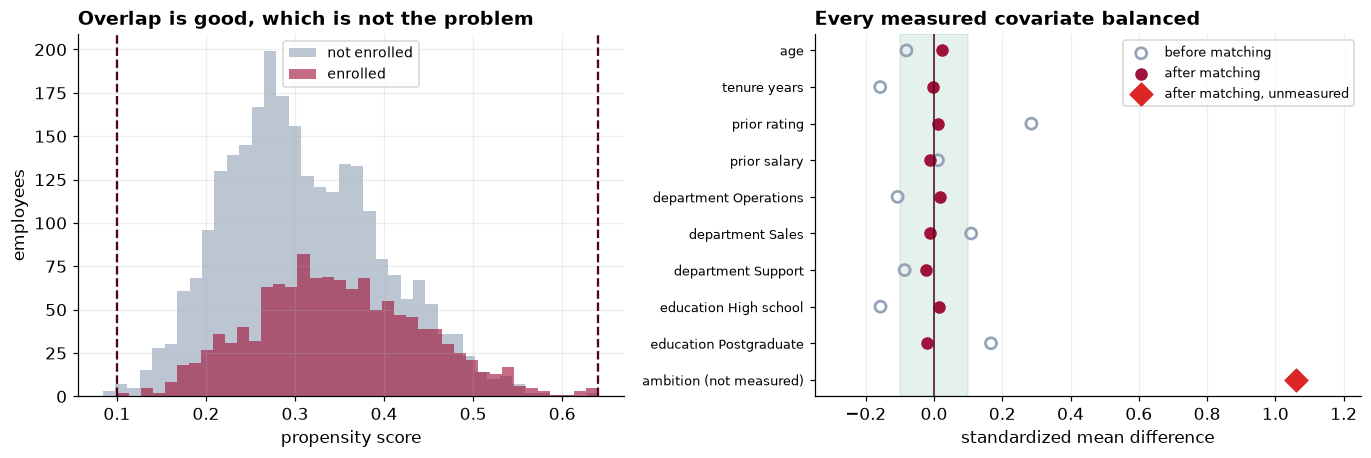

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.3))

ax = axes[0]
ax.hist(c0.ps, bins=40, alpha=0.62, color=MUT, label="not enrolled", edgecolor="none")
ax.hist(t0.ps, bins=40, alpha=0.62, color=RS, label="enrolled", edgecolor="none")
ax.axvline(lo, color=DK, ls="--", lw=1.5); ax.axvline(hi, color=DK, ls="--", lw=1.5)
ax.set_xlabel("propensity score"); ax.set_ylabel("employees")
ax.set_title("Overlap is good, which is not the problem"); ax.legend(fontsize=9)

ax = axes[1]
names = list(Xs.columns) + ["ambition (not measured)"]
bef = [smd(sup.index, c_) for c_ in Xs.columns] + [np.nan]
aft = [smd(matched.index, c_) for c_ in Xs.columns] + [smd_amb]
yy = np.arange(len(names))
ax.axvspan(-0.1, 0.1, color=GD, alpha=0.10)
ax.scatter(bef[:-1], yy[:-1], s=52, facecolor="none", edgecolor=MUT, lw=1.8, label="before matching")
ax.scatter(aft[:-1], yy[:-1], s=52, color=RS, label="after matching")
ax.scatter([aft[-1]], [yy[-1]], s=110, color="#dc2626", marker="D", zorder=5,
           label="after matching, unmeasured")
ax.axvline(0, color=DK, lw=1)
ax.set_yticks(yy); ax.set_yticklabels([n.replace("_"," ") for n in names], fontsize=8.5)
ax.invert_yaxis(); ax.set_xlabel("standardized mean difference")
ax.set_xlim(-0.35, 1.25); ax.set_title("Every measured covariate balanced")
ax.legend(fontsize=8.5, loc="upper right"); ax.grid(axis="y", alpha=0)
plt.tight_layout(); plt.show()

**Left:** the propensity scores overlap almost completely, so common support is not the difficulty here; only five employees have no counterpart. **Right:** the balance plot that would go in the appendix. Every measured covariate moves inside the shaded target band. The red diamond is the variable nobody measured, still separated by more than one standard deviation after matching, and it is off the scale that the rest of the plot is drawn on.

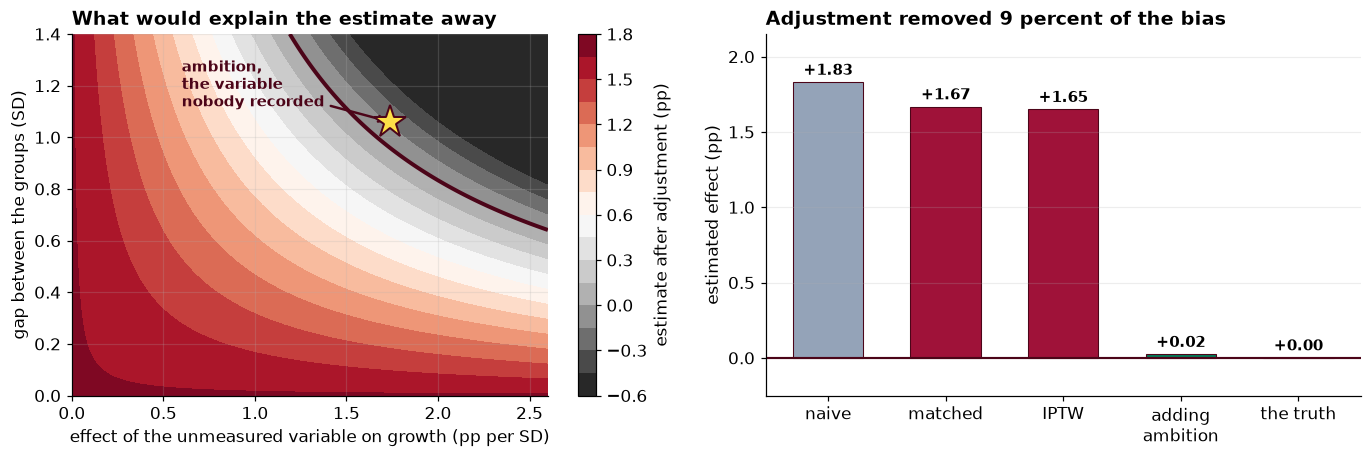

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.3))

ax = axes[0]
cs = ax.contourf(G, D_, np.clip(adjusted, -0.6, dm), levels=18, cmap="RdGy_r")
ax.contour(G, D_, adjusted, levels=[0], colors=[DK], linewidths=2.6)
ax.plot(fit_with.params["ambition_index"], smd_amb, marker="*", ms=22, color="#fde047",
        markeredgecolor=DK, markeredgewidth=1.3, zorder=6)
ax.annotate("ambition,\nthe variable\nnobody recorded",
            xy=(fit_with.params["ambition_index"], smd_amb), xytext=(0.60, 1.12),
            fontsize=9.5, fontweight="bold", color=DK,
            arrowprops=dict(arrowstyle="->", color=DK, lw=1.6))
ax.set_xlabel("effect of the unmeasured variable on growth (pp per SD)")
ax.set_ylabel("gap between the groups (SD)")
ax.set_title("What would explain the estimate away")
plt.colorbar(cs, ax=ax, label="estimate after adjustment (pp)")

ax = axes[1]
labs = ["naive", "matched", "IPTW", "adding\nambition", "the truth"]
vals = [diff0, dm, mu1-mu0, fit_with.params["enrolled"], 0.0]
cols = [MUT, RS, RS, GD, DK]
bb = ax.bar(labs, vals, color=cols, edgecolor=DK, lw=0.7, width=0.6)
for r_, v in zip(bb, vals):
    ax.text(r_.get_x()+r_.get_width()/2, v+0.05, f"{v:+.2f}", ha="center",
            fontweight="bold", fontsize=10)
ax.axhline(0, color=DK, lw=1.4)
ax.set_ylabel("estimated effect (pp)"); ax.set_ylim(-0.25, 2.15)
ax.set_title("Adjustment removed 9 percent of the bias"); ax.grid(axis="x", alpha=0)
plt.tight_layout(); plt.show()

**Left:** every combination of confounder strength that would drive the estimate to zero lies above the dark curve. The star is where the real variable sits, comfortably inside the region. A sensitivity analysis cannot tell you that the star exists, but it tells you exactly how big it would have to be, which is a question a manager can answer. **Right:** the whole chapter as five bars.

## Step 12 &middot; Ethics, bias, and limits
- **Balance on measured covariates is not evidence about unmeasured ones.** It is easy to present a balance table as though it established comparability. It establishes comparability on the columns in the table, and a reader who is not told what is missing cannot judge how much that is worth.
- **Report the sensitivity analysis next to the estimate, not in an appendix.** An E-value is a single number and it belongs in the abstract. Its absence should be read as a claim that no confounder could exist, which nobody would defend in words.
- **A large E-value is not a clean bill of health.** This estimate would need a confounder with a risk ratio of about 3.3 on both sides, which sounds demanding until you ask a manager whether ambition predicts both signing up for training and getting promoted.
- **Adjust only on pre-treatment variables.** Every covariate here was recorded before enrollment. Adjusting for something measured afterward, such as the number of projects led during the year, would have removed part of the effect being estimated rather than part of the confounding.
- **Say what estimand you are targeting.** This is an ATT: the effect on the people who actually enrolled. It is not what would happen if the program were made compulsory, and reporting it as though it were would overstate what is known.
- **The discarded are part of the result.** Twenty-seven enrolled employees had no acceptable match and were dropped, along with 120 for missing covariates. That changes who the estimate is about, and it should be stated rather than buried in a pipeline.
- **This is a study of people's careers.** An analysis concluding that a popular program does nothing has consequences for the people who run it and the people who took it. That is a reason to be careful and transparent about the uncertainty, not a reason to soften the finding.

---
**From analysis to report.** The notebook carries the chain: the plan written before the outcomes were linked, the cleaning and what it discarded, the naive difference, the propensity model, common support, matching with a caliper, a balance table that passes on every measured covariate, agreement between matching and weighting, an E-value and a sensitivity surface, and only then the sheet that shows the whole estimate was selection. The written reports turn it into advice an HR director can act on and a technical account a fellow statistician can audit. Automate the evidence; author the argument.